# Chemical Compound Classification

## Importing Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras import backend as K

Using TensorFlow backend.


## Reading Data

In [2]:
data=pd.read_csv('musk_csv.csv')

In [3]:
data.head()

,ID,molecule_name,conformation_name,f1,f2,f3,f4,f5,f6,f7,...,f158,f159,f160,f161,f162,f163,f164,f165,f166,class
0,1,MUSK-211,211_1+1,46,-108,-60,-69,-117,49,38,...,-308,52,-7,39,126,156,-50,-112,96,1
1,2,MUSK-211,211_1+10,41,-188,-145,22,-117,-6,57,...,-59,-2,52,103,136,169,-61,-136,79,1
2,3,MUSK-211,211_1+11,46,-194,-145,28,-117,73,57,...,-134,-154,57,143,142,165,-67,-145,39,1
3,4,MUSK-211,211_1+12,41,-188,-145,22,-117,-7,57,...,-60,-4,52,104,136,168,-60,-135,80,1
4,5,MUSK-211,211_1+13,41,-188,-145,22,-117,-7,57,...,-60,-4,52,104,137,168,-60,-135,80,1


## Data Cleaning

In [4]:
data.dtypes[data.dtypes!='int64']

molecule_name        object
conformation_name    object
dtype: object

In [5]:
data['molecule_name'].value_counts()

NON-MUSK-j146    1044
NON-MUSK-252     1010
NON-MUSK-j147     911
NON-MUSK-f146     383
NON-MUSK-288      344
                 ... 
NON-MUSK-308        2
NON-MUSK-309        2
NON-MUSK-290        2
NON-MUSK-j97        1
NON-MUSK-j96        1
Name: molecule_name, Length: 102, dtype: int64

In [6]:
data['conformation_name'].value_counts()

252_3+22      1
270_1+35      1
251_1+39      1
j146_2+176    1
197_1+84      1
             ..
288_4+54      1
361_3+2       1
j147_1+219    1
215_1+32      1
199_1+17      1
Name: conformation_name, Length: 6598, dtype: int64

There are two columns with non-integral features. Out of which only 'molecule_name' seems to be categorical while 'conformation_name' is unique for each and every row. So, we will ignore it considering it as an ID kind of feature.

In [7]:
data.drop(['conformation_name','ID'],axis=1,inplace=True)

In [8]:
data['class'].value_counts()

0    5581
1    1017
Name: class, dtype: int64

So, it is a binary classification problem.

### Convert 'molecular_name' to numerical type

In [9]:
data['molecule_name']= pd.Categorical(data['molecule_name'])

In [10]:
LE = LabelEncoder()
data['molecule_name'] = LE.fit_transform(data['molecule_name'])

## Train-Test Split

In [11]:
y=data['class']

In [12]:
data.drop(['class'],inplace=True,axis=1)

In [13]:
X_train,X_test,y_train,y_test=train_test_split(data,y,test_size=0.2,random_state=42,stratify=y)
X_train,X_cv,y_train,y_cv=train_test_split(X_train,y_train,test_size=0.2,random_state=42,stratify=y_train)

## Normalizing Data

In [14]:
scalar=MinMaxScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)
X_cv=scalar.transform(X_cv)

## Create Model

### Model Architecture

In [15]:
model = Sequential()
model.add(Dense(32, input_shape=(X_train.shape[1],),activation='relu'))
model.add(Dense(64, input_shape=(X_train.shape[1],),activation='relu'))
model.add(Dense(32, input_shape=(X_train.shape[1],),activation='relu'))
model.add(Dense(1,activation='sigmoid'))

Instructions for updating:
Colocations handled automatically by placer.


### Defining Custom Performance Metrics

In [16]:
def recall_m(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = true_positives / (possible_positives + K.epsilon())
        return recall

def precision_m(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + K.epsilon())
        return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

### Compile Model

In [17]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy',f1_m,precision_m, recall_m])

### Model Summary

In [18]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 32)                5376      
_________________________________________________________________
dense_2 (Dense)              (None, 64)                2112      
_________________________________________________________________
dense_3 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_4 (Dense)              (None, 1)                 33        
Total params: 9,601
Trainable params: 9,601
Non-trainable params: 0
_________________________________________________________________


### Training Model

In [19]:
history=model.fit(X_train,y_train, epochs=20, batch_size=64,validation_data=(X_cv,y_cv))

Instructions for updating:
Use tf.cast instead.
Train on 4222 samples, validate on 1056 samples
Epoch 1/20
4222/4222 [==============================] - 0s 96us/step - loss: 0.3996 - acc: 0.8413 - f1_m: 0.0013 - precision_m: 9.4742e-04 - recall_m: 0.0019 - val_loss: 0.3159 - val_acc: 0.8456 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00
Epoch 2/20
4222/4222 [==============================] - 0s 23us/step - loss: 0.2459 - acc: 0.8918 - f1_m: 0.3939 - precision_m: 0.6751 - recall_m: 0.3017 - val_loss: 0.1489 - val_acc: 0.9479 - val_f1_m: 0.7885 - val_precision_m: 0.9846 - val_recall_m: 0.6677
Epoch 3/20
4222/4222 [==============================] - 0s 22us/step - loss: 0.1207 - acc: 0.9581 - f1_m: 0.8417 - precision_m: 0.9574 - recall_m: 0.7702 - val_loss: 0.0757 - val_acc: 0.9801 - val_f1_m: 0.9339 - val_precision_m: 0.9423 - val_recall_m: 0.9318
Epoch 4/20
4222/4222 [==============================] - 0s 25us/step - loss: 0.0643 - acc: 0.9789 - f1_m: 0.927

### Performance Metrics Plots

#### Accuracy

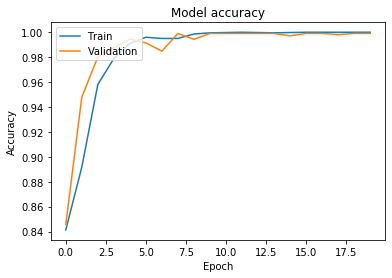

In [20]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#### Loss

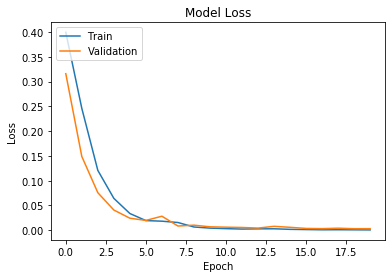

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#### F1-Score

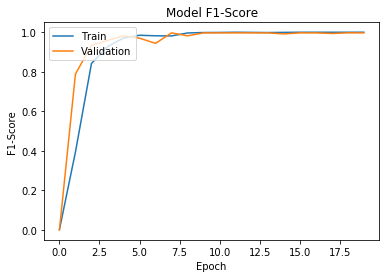

In [22]:
plt.plot(history.history['f1_m'])
plt.plot(history.history['val_f1_m'])
plt.title('Model F1-Score')
plt.ylabel('F1-Score')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#### Precision

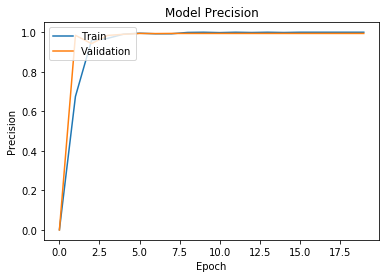

In [23]:
plt.plot(history.history['precision_m'])
plt.plot(history.history['val_precision_m'])
plt.title('Model Precision')
plt.ylabel('Precision')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#### Recall

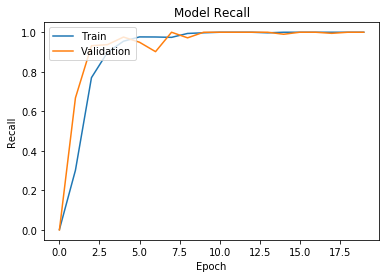

In [37]:
plt.plot(history.history['recall_m'])
plt.plot(history.history['val_recall_m'])
plt.title('Model Recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

##### The Deep Learning model is very simple and also it is achieving a good performance as the data provided is not of too complex nature.

In [25]:
test_evaluation=model.evaluate(X_test,y_test)

1320/1320 [==============================] - 0s 25us/step


In [26]:
print("Test Loss=>",test_evaluation[0])
print("Test Accuracy=>",test_evaluation[1])
print("Test F1-Score=>",test_evaluation[2])
print("Test Precision=>",test_evaluation[3])
print("Test Recall=>",test_evaluation[4])

Test Loss=> 0.0039769002685330415
Test Accuracy=> 0.9992424242424243
Test F1-Score=> 0.9920745878508597
Test Precision=> 0.9904761877926913
Test Recall=> 0.9939393910494718


In [27]:
model.save('my_model.h5')